In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving global-data-on-sustainable-energy.csv to global-data-on-sustainable-energy.csv


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [4]:
df.info()
df.shape
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

,0
Entity,0
Year,0
Access to electricity (% of population),10
Access to clean fuels for cooking,169
Renewable-electricity-generating-capacity-per-capita,931
Financial flows to developing countries (US $),2089
Renewable energy share in the total final energy consumption (%),194
Electricity from fossil fuels (TWh),21
Electricity from nuclear (TWh),126
Electricity from renewables (TWh),21


In [5]:
df.drop_duplicates(inplace=True)
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
df.isnull().sum()

,0
Entity,0
Year,0
Access to electricity (% of population),0
Access to clean fuels for cooking,0
Renewable-electricity-generating-capacity-per-capita,0
Financial flows to developing countries (US $),0
Renewable energy share in the total final energy consumption (%),0
Electricity from fossil fuels (TWh),0
Electricity from nuclear (TWh),0
Electricity from renewables (TWh),0


In [6]:
features = df[[
    'Access to electricity (% of population)',
    'Renewable-electricity-generating-capacity-per-capita',
    'Renewable energy share in the total final energy consumption (%)',
    'Value_co2_emissions_kt_by_country',
    'gdp_per_capita'
]]

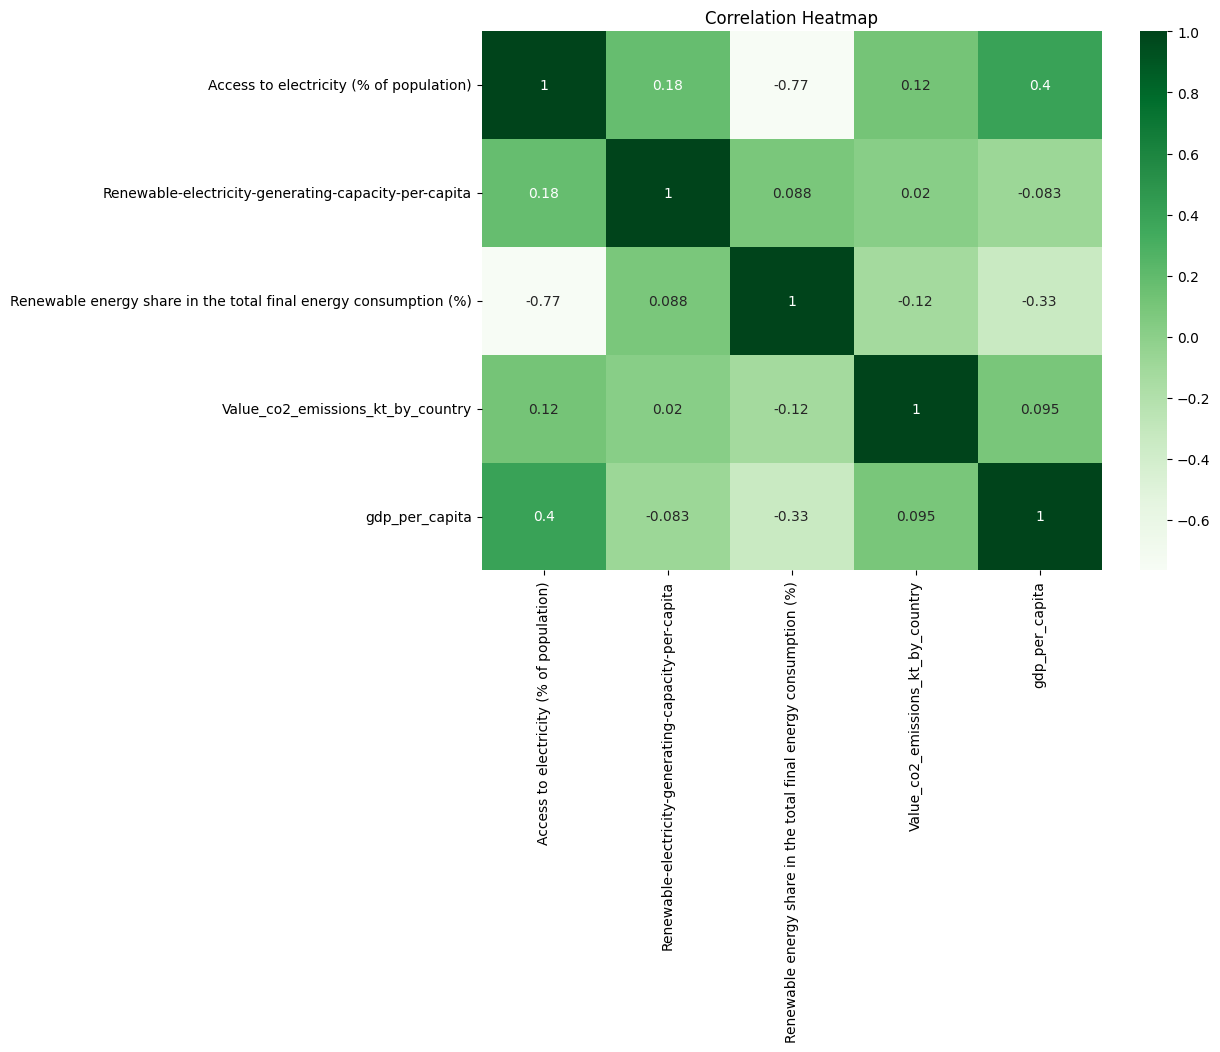

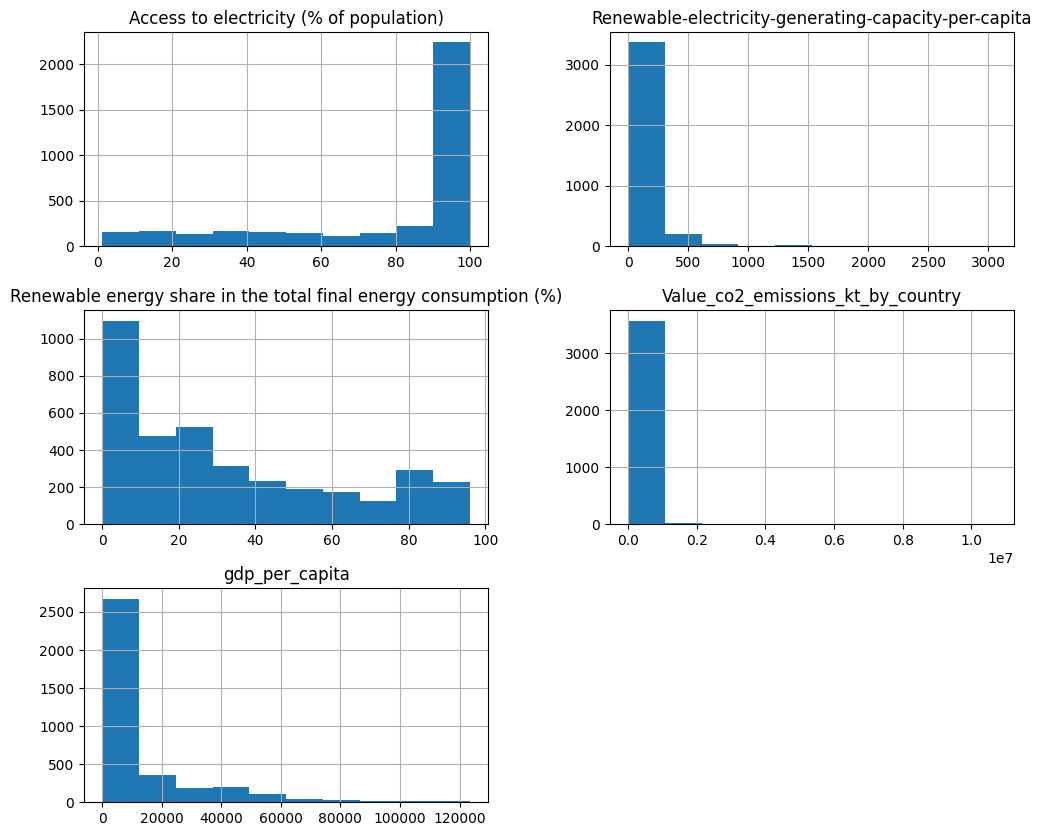

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(features.corr(), annot=True, cmap="Greens")
plt.title("Correlation Heatmap")
plt.show()

features.hist(figsize=(12,10))
plt.show()

In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

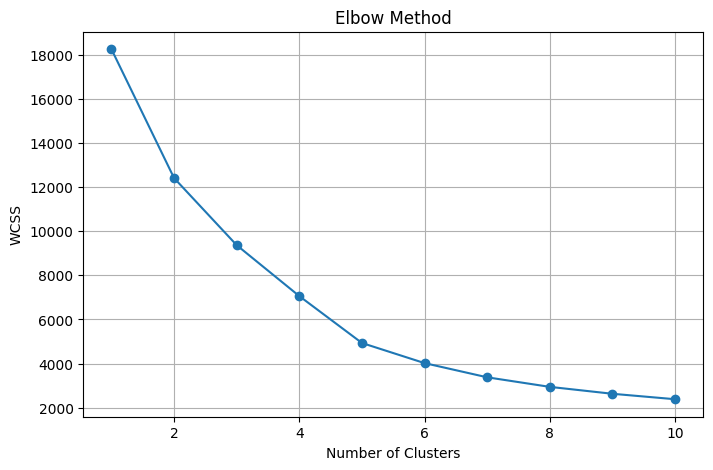

In [9]:

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)


#plot
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
df['Cluster'] = kmeans.fit_predict(scaled_features)

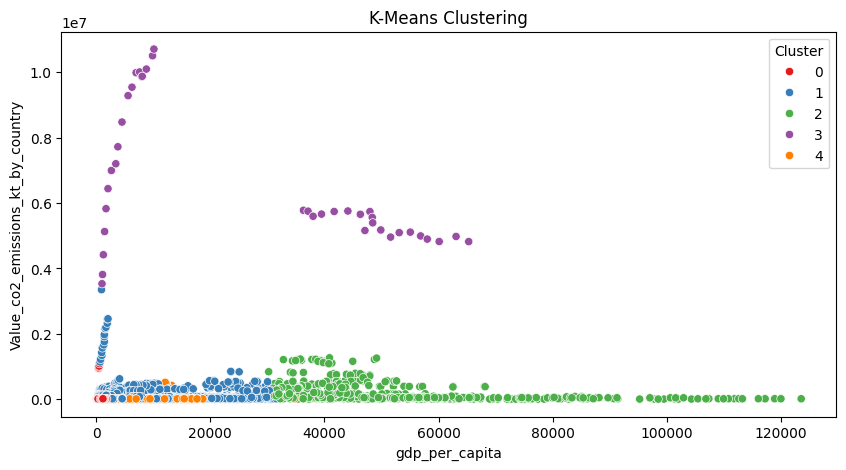

In [11]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='gdp_per_capita',
    y='Value_co2_emissions_kt_by_country',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.title("K-Means Clustering")
plt.show()

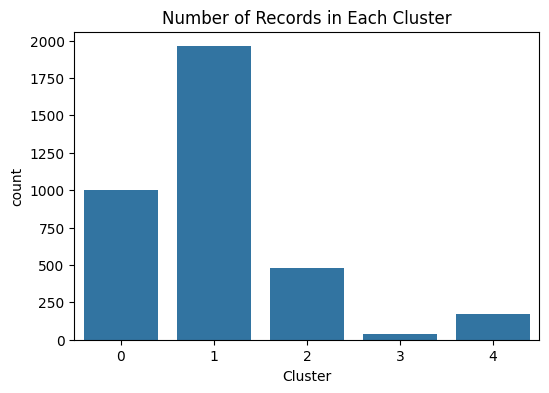

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=df)
plt.title("Number of Records in Each Cluster")
plt.show()

In [13]:
score = silhouette_score(scaled_features, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.49278112804442564


In [14]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers = pd.DataFrame(
    centers,
    columns=features.columns
)

cluster_centers

,Access to electricity (% of population),Renewable-electricity-generating-capacity-per-capita,Renewable energy share in the total final energy consumption (%),Value_co2_emissions_kt_by_country,gdp_per_capita
0,35.470701,28.731812,69.713694,1.255105e+04,1444.153743
1,94.114121,72.701642,15.834870,7.877718e+04,8464.485122
2,100.000000,41.426743,17.080376,1.865073e+05,53907.968464
3,99.579162,123.502821,11.551282,6.563515e+06,27768.321952
4,96.179820,831.671988,46.531579,4.145749e+04,6264.306606
